In [1]:
import pandas as pd
import numpy as np
import re
import nltk
import matplotlib.pyplot as plt
import seaborn as sns

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_csv("spam_ham_dataset.csv")
print("Dataset Shape:", df.shape)
df.head()


Dataset Shape: (5171, 2)


,label,text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see..."
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar..."
3,spam,"Subject: photoshop , windows , office . cheap ..."
4,ham,Subject: re : indian springs\r\nthis deal is t...


label
ham     3672
spam    1499
Name: count, dtype: int64


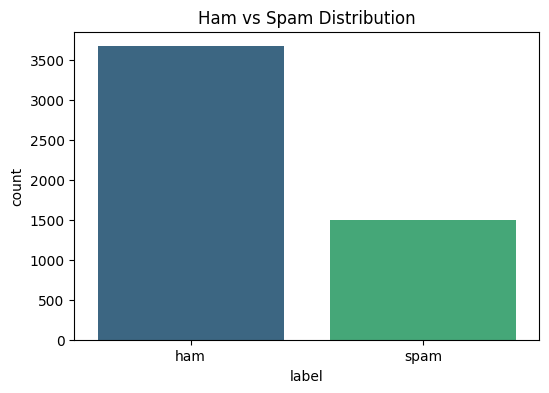

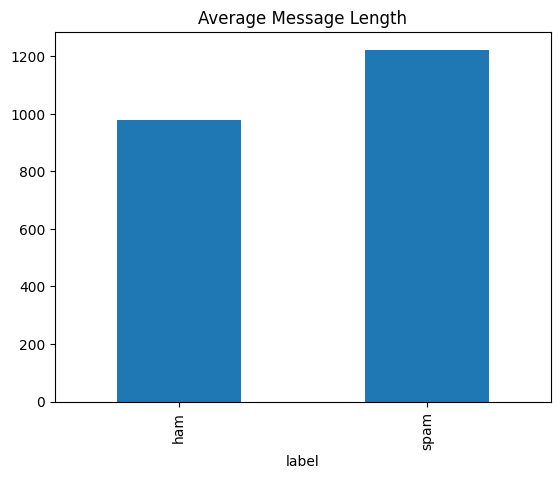

In [3]:
# Check class distribution
print(df['label'].value_counts())

# Visualize
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, palette='viridis')
plt.title('Ham vs Spam Distribution')
plt.show()

# Average message length
df['length'] = df['text'].apply(len)
df.groupby('label')['length'].mean().plot(kind='bar')
plt.title('Average Message Length')
plt.show()

In [4]:
def clean_text(text):
    """Simple text cleaning function"""
    # Convert to lowercase
    text = text.lower()
    # Remove special characters and numbers
    text = re.sub(r'[^a-z\s]', '', text)
    # Remove extra spaces
    text = ' '.join(text.split())
    return text

# Apply cleaning
df['clean_message'] = df['text'].apply(clean_text)

# Show before and after
print("Original:", df['text'].iloc[0])
print("Cleaned: ", df['clean_message'].iloc[0])

Original: Subject: enron methanol ; meter # : 988291
this is a follow up to the note i gave you on monday , 4 / 3 / 00 { preliminary
flow data provided by daren } .
please override pop ' s daily volume { presently zero } to reflect daily
activity you can obtain from gas control .
this change is needed asap for economics purposes .
Cleaned:  subject enron methanol meter this is a follow up to the note i gave you on monday preliminary flow data provided by daren please override pop s daily volume presently zero to reflect daily activity you can obtain from gas control this change is needed asap for economics purposes


In [5]:
X = df['clean_message']
y = df['label']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.2, 
                                                    random_state=42,
                                                    stratify=y)

In [7]:
print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 4136
Testing samples: 1035


In [8]:
# Convert text into numerical features
vectorizer = TfidfVectorizer(max_features=5000, stop_words='english')

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

print("Shape of training features:", X_train_vec.shape)

Shape of training features: (4136, 5000)


In [9]:
# Train a simple Naive Bayes model
model = MultinomialNB()
model.fit(X_train_vec, y_train)



MultinomialNB()

Accuracy: 0.9488 or 94.88%

Classification Report:
              precision    recall  f1-score   support

         ham       0.97      0.96      0.96       735
        spam       0.90      0.93      0.91       300

    accuracy                           0.95      1035
   macro avg       0.93      0.94      0.94      1035
weighted avg       0.95      0.95      0.95      1035



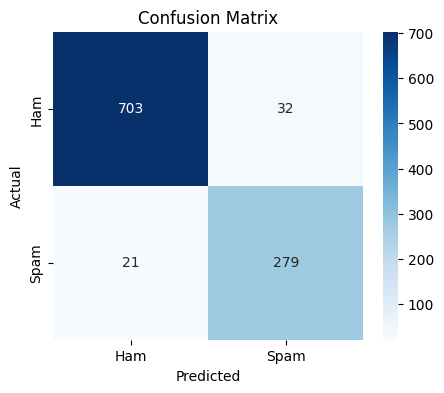

In [10]:
# Make predictions
y_pred = model.predict(X_test_vec)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f} or {accuracy*100:.2f}%")

# Detailed Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Ham', 'Spam'], 
            yticklabels=['Ham', 'Spam'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [11]:
def predict_spam(message):
    cleaned = clean_text(message)
    vectorized = vectorizer.transform([cleaned])
    prediction = model.predict(vectorized)[0]
    probability = model.predict_proba(vectorized)[0]
    
    print(f"Message: {message}")
    print(f"Prediction: {'SPAM' if prediction == 'spam' else 'Ham'}")
    print(f"Spam Probability: {probability[1]:.4f}")

# Test some messages
predict_spam("Congratulations! You won a free prize. Click here to claim.")
predict_spam("Hey, are we meeting tomorrow at 5pm?")
predict_spam("URGENT! Your account will be suspended. Verify now.")

Message: Congratulations! You won a free prize. Click here to claim.
Prediction: SPAM
Spam Probability: 0.8641
Message: Hey, are we meeting tomorrow at 5pm?
Prediction: Ham
Spam Probability: 0.0421
Message: URGENT! Your account will be suspended. Verify now.
Prediction: Ham
Spam Probability: 0.2423
